# 02 - LSTM Demand Forecasting

End-to-end PyTorch LSTM that predicts the next 30 days of daily demand
for the top 50 products. Six sections, one per ML lifecycle stage:

1. Data preparation
2. EDA (LSTM-specific)
3. Feature engineering
4. Model selection & training
5. Evaluation
6. Fine-tuning

## 1. Data preparation

Calls `src.preprocessing.prepare_data()` end-to-end. This writes:

- `data/processed/daily.csv`
- `data/processed/scalers.pkl`
- `data/processed/splits.json`

The team's RNN/RF/GP notebooks will read the same files.

In [1]:
import sys, os
# Make project root importable when this notebook is run from notebooks/
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))
os.chdir(os.path.abspath(os.path.join(os.getcwd(), "..")))  # so sales.csv resolves

import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.utils.data import DataLoader

from src import preprocessing
from src.models import lstm_model

torch.manual_seed(42)
np.random.seed(42)

In [2]:
splits = preprocessing.prepare_data(
    csv_path="sales.csv",
    n_products=50,
    full_history_days=761,
    val_days=60,
    test_frac=0.20,
    outdir="data/processed",
)
splits

{'train_start': '2022-08-28',
 'train_end': '2024-02-27',
 'val_start': '2024-02-28',
 'val_end': '2024-04-27',
 'test_start': '2024-04-28',
 'test_end': '2024-09-26'}

In [3]:
daily = pd.read_csv("data/processed/daily.csv", parse_dates=["date"])
with open("data/processed/scalers.pkl", "rb") as f:
    scalers = pickle.load(f)

print(f"top-50 products kept: {daily['item_id'].nunique()}")
print(f"days per product:     {daily.groupby('item_id')['date'].nunique().min()}")
print(f"split boundaries:     {splits}")
daily.head()

top-50 products kept: 50
days per product:     761
split boundaries:     {'train_start': '2022-08-28', 'train_end': '2024-02-27', 'val_start': '2024-02-28', 'val_end': '2024-04-27', 'test_start': '2024-04-28', 'test_end': '2024-09-26'}


,item_id,date,quantity,dow_sin,dow_cos,dom_sin,dom_cos,month_sin,month_cos,quantity_scaled
0,060534551cba,2022-08-28,85.0,-0.781831,0.623490,-0.724793,0.688967,-0.500000,-0.866025,0.438034
1,060534551cba,2022-08-29,90.0,0.000000,1.000000,-0.571268,0.820763,-0.500000,-0.866025,0.464744
2,060534551cba,2022-08-30,75.0,0.781831,0.623490,-0.394356,0.918958,-0.500000,-0.866025,0.384615
3,060534551cba,2022-08-31,83.0,0.974928,-0.222521,-0.201299,0.979530,-0.500000,-0.866025,0.427350
4,060534551cba,2022-09-01,119.0,0.433884,-0.900969,0.000000,1.000000,-0.866025,-0.500000,0.619658


## 2. EDA (LSTM-specific)

Now that we have filtered to the top 50 products and added calendar features,
we look at *this* dataset (not the raw 28k-product `sales.csv`) - what
patterns will the LSTM need to learn?

In [4]:
totals = daily.groupby("item_id")["quantity"].sum().sort_values(ascending=False)
representatives = [totals.index[0], totals.index[24], totals.index[-1]]
representatives

['b0d24502fb66', '694f2c19abbf', '1de18c13710d']

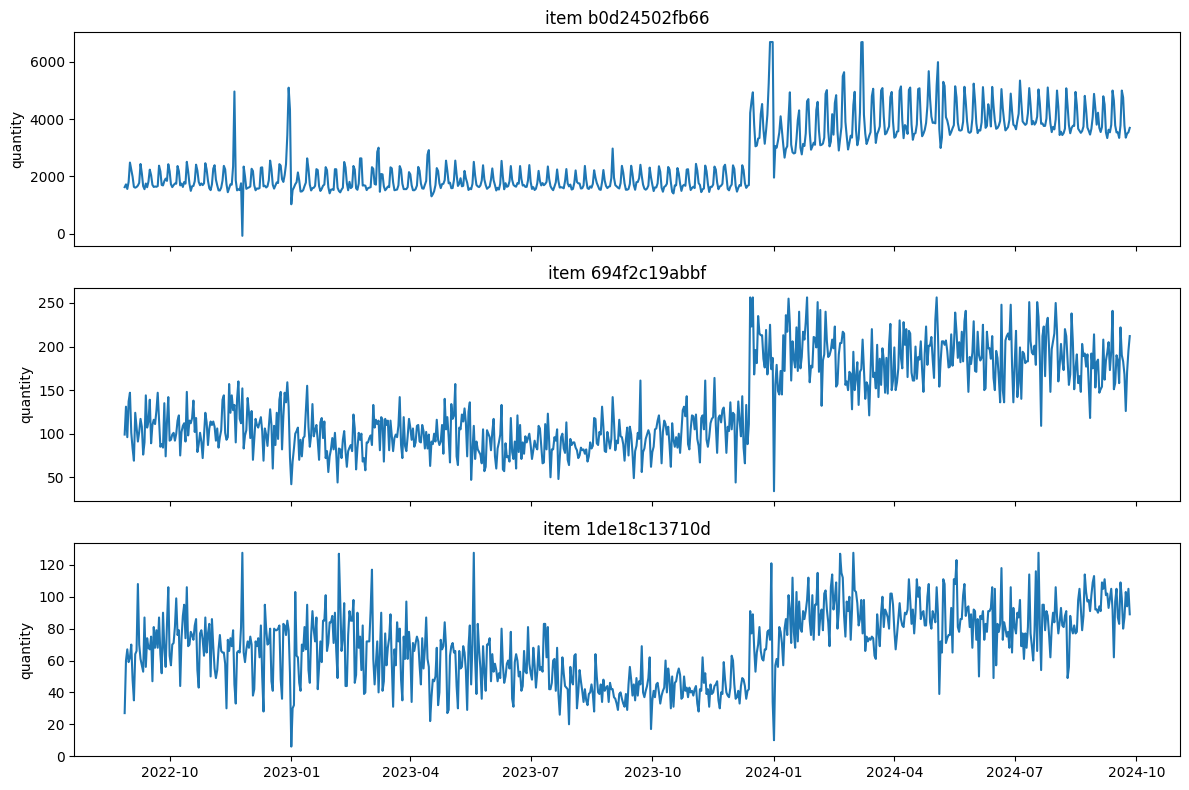

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
for ax, item_id in zip(axes, representatives):
    sub = daily[daily["item_id"] == item_id].sort_values("date")
    ax.plot(sub["date"], sub["quantity"])
    ax.set_title(f"item {item_id}")
    ax.set_ylabel("quantity")
plt.tight_layout(); plt.show()

C:\Users\raymo\AppData\Local\Temp\ipykernel_30832\3828764200.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"])


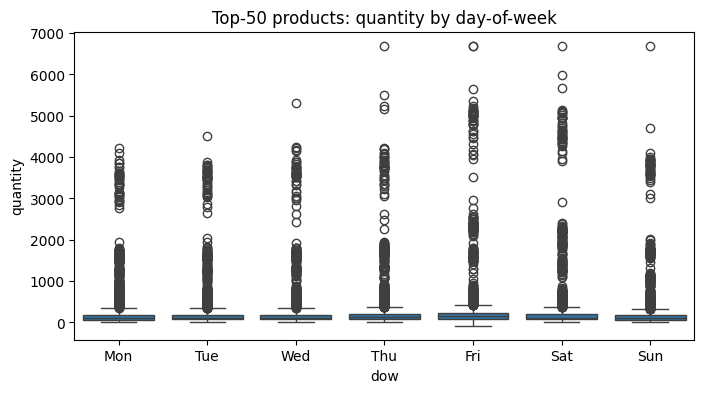

In [6]:
daily["dow"] = daily["date"].dt.dayofweek
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=daily, x="dow", y="quantity", ax=ax)
ax.set_xticklabels(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"])
ax.set_title("Top-50 products: quantity by day-of-week")
plt.show()

In [7]:
print("quantity_scaled - should be in [0, 1] for training rows:")
train_end = pd.Timestamp(splits["train_end"])
train_rows = daily[daily["date"] <= train_end]
print(train_rows["quantity_scaled"].describe()[["min", "max", "mean"]])

quantity_scaled - should be in [0, 1] for training rows:
min     0.0000
max     1.0000
mean    0.3438
Name: quantity_scaled, dtype: float64


## 3. Feature engineering

What we are doing in this section:

1. Build a `product_to_idx` mapping (string item IDs - 0..49 integers for the embedding).
2. Slice `daily.csv` into the three time periods (train, val, test) using `splits.json`.
3. For each slice, run `create_sequences()` to generate `(60-day input, 30-day target)` pairs.
4. Wrap each slice in an `LSTMDataset` and a PyTorch `DataLoader`.

In [8]:
product_to_idx = {pid: i for i, pid in enumerate(sorted(daily["item_id"].unique()))}
idx_to_product = {i: pid for pid, i in product_to_idx.items()}
len(product_to_idx)

50

In [9]:
train_end = pd.Timestamp(splits["train_end"])
val_end   = pd.Timestamp(splits["val_end"])

LOOKBACK = 60
HORIZON = 30

train_slice = daily[daily["date"] <= train_end].copy()
val_slice   = daily[(daily["date"] >  train_end - pd.Timedelta(days=LOOKBACK))
                    & (daily["date"] <= val_end)].copy()
test_slice  = daily[(daily["date"] >  val_end   - pd.Timedelta(days=LOOKBACK))].copy()

print(f"train rows: {len(train_slice):,}  ({train_slice['date'].min()} -> {train_slice['date'].max()})")
print(f"val rows:   {len(val_slice):,}    ({val_slice['date'].min()} -> {val_slice['date'].max()})")
print(f"test rows:  {len(test_slice):,}   ({test_slice['date'].min()} -> {test_slice['date'].max()})")

train rows: 27,450  (2022-08-28 00:00:00 -> 2024-02-27 00:00:00)
val rows:   6,000    (2023-12-30 00:00:00 -> 2024-04-27 00:00:00)
test rows:  10,600   (2024-02-28 00:00:00 -> 2024-09-26 00:00:00)


In [10]:
X_qty_tr, X_cal_tr, idx_tr, y_tr = preprocessing.create_sequences(
    train_slice, product_to_idx, lookback=LOOKBACK, horizon=HORIZON)
X_qty_va, X_cal_va, idx_va, y_va = preprocessing.create_sequences(
    val_slice,   product_to_idx, lookback=LOOKBACK, horizon=HORIZON)
X_qty_te, X_cal_te, idx_te, y_te = preprocessing.create_sequences(
    test_slice,  product_to_idx, lookback=LOOKBACK, horizon=HORIZON)

print(f"train windows: {X_qty_tr.shape}")
print(f"val windows:   {X_qty_va.shape}")
print(f"test windows:  {X_qty_te.shape}")

train windows: (23000, 60, 1)
val windows:   (1550, 60, 1)
test windows:  (6150, 60, 1)


In [11]:
BATCH_SIZE = 64

train_ds = lstm_model.LSTMDataset(X_qty_tr, X_cal_tr, idx_tr, y_tr)
val_ds   = lstm_model.LSTMDataset(X_qty_va, X_cal_va, idx_va, y_va)
test_ds  = lstm_model.LSTMDataset(X_qty_te, X_cal_te, idx_te, y_te)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

print("train batches:", len(train_loader))
print("val batches:  ", len(val_loader))
print("test batches: ", len(test_loader))

train batches: 360
val batches:   25
test batches:  97


## 4. Model selection & training

Before we train, here is a plain-language tour of what an LSTM is and why
we are using one. If you already know LSTMs, you can skip the next six
sub-sections and jump to "Build the model."

### What problem do LSTMs solve?

A regular ("vanilla") RNN reads a sequence one element at a time, updating
an internal hidden state. The trouble is that vanilla RNNs **forget**:
information from the start of the sequence gets diluted as new elements
arrive, so they struggle to connect "what happened 60 days ago" to "what
will happen tomorrow."

LSTMs (Long Short-Term Memory networks, Hochreiter & Schmidhuber, 1997)
add a separate **cell state** that flows through time with minimal
modification, so information can persist over long ranges. In addition,
three learned "gates" decide what to forget, what to add, and what to
output at each step.

### The three gates

At every timestep, an LSTM cell computes three "gates" - each one a
sigmoid-activated linear transformation of the previous hidden state and
the current input:

| Gate    | Question it answers                                  |
|---------|------------------------------------------------------|
| Forget  | What of the previous cell state should I drop?       |
| Input   | What new information should I write into the cell?   |
| Output  | Of the cell's contents, what do I expose now?        |

The math (PyTorch handles it for us):

```
f_t = sigma(W_f . [h_{t-1}, x_t] + b_f)   # forget
i_t = sigma(W_i . [h_{t-1}, x_t] + b_i)   # input
g_t = tanh(W_g . [h_{t-1}, x_t] + b_g)
o_t = sigma(W_o . [h_{t-1}, x_t] + b_o)   # output

c_t = f_t * c_{t-1} + i_t * g_t           # new cell state
h_t = o_t * tanh(c_t)                     # new hidden state
```

### Hidden state vs cell state

Two pieces of "memory" travel through the LSTM:

- **Cell state `c_t`** - the LSTM's long-term memory. Information written
  here can survive for many timesteps because the only operations that
  touch it are element-wise (no matrix multiplications that would dilute
  it).
- **Hidden state `h_t`** - the LSTM's short-term, exposed scratchpad. This
  is what the next layer reads.

After 60 timesteps, we take the **final hidden state** (`h_n[-1]` in
PyTorch - the top layer's hidden state from the last timestep) and feed it
into a `Linear` layer that produces our 30-day forecast.

### Why an embedding for `product_idx`?

We have 50 products. We could one-hot encode them (a 50-dim vector with
49 zeros and a single 1) - but that wastes parameters and treats every
product as equally distant from every other.

An **embedding** is a small lookup table: each product gets its own
learned vector (we use 8 dimensions). Products with similar demand
patterns will, after training, end up with similar vectors. The model
then concatenates the embedding with the per-day quantity and calendar
features at every timestep, so the LSTM "knows which product it is
looking at" throughout the entire sequence.

### Why a 60->30 sliding window?

Each training example is a `(60-day input, 30-day target)` pair. We
slide that window across the time series with stride 1, generating many
examples per product:

```
                day index
   0 ----------- 59 60 ----------- 89    <- example 1
       1 ----------- 60 61 ----------- 90  <- example 2
                ...
```

This gives the model many opportunities to learn the
"given the last 60 days, what do the next 30 look like?" mapping. The
choice of 60 (lookback) and 30 (horizon) is a hyperparameter - we will
sweep it in Section 6.

### Build the model

In [12]:
N_PRODUCTS = len(product_to_idx)
HIDDEN_SIZE = 64
NUM_LAYERS = 2
DROPOUT = 0.2
EMBED_DIM = 8

model = lstm_model.LSTMForecaster(
    n_products=N_PRODUCTS,
    embed_dim=EMBED_DIM,
    lookback=LOOKBACK,
    horizon=HORIZON,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    n_calendar=6,
)
print(model)
n_params = sum(p.numel() for p in model.parameters())
print(f"trainable parameters: {n_params:,}")

LSTMForecaster(
  (product_embed): Embedding(50, 8)
  (lstm): LSTM(15, 64, num_layers=2, batch_first=True, dropout=0.2)
  (head): Linear(in_features=64, out_features=30, bias=True)
)
trainable parameters: 56,366


In [13]:
# Pull one example out of the train set and walk it through the layers manually,
# printing the shape after each step.
past_qty, calendar, prod_idx, target = train_ds[0]
past_qty = past_qty.unsqueeze(0)
calendar = calendar.unsqueeze(0)
prod_idx = prod_idx.unsqueeze(0)

print("Input shapes:")
print(f"  past_qty:  {past_qty.shape}")
print(f"  calendar:  {calendar.shape}")
print(f"  prod_idx:  {prod_idx.shape}")

embed = model.product_embed(prod_idx)
print()
print(f"product_embed output: {embed.shape}")

embed_seq = embed.unsqueeze(1).expand(-1, LOOKBACK, -1)
combined = torch.cat([past_qty, calendar, embed_seq], dim=-1)
print(f"combined input to LSTM: {combined.shape}")

with torch.no_grad():
    _, (h_n, _) = model.lstm(combined)
    last_hidden = h_n[-1]
    forecast = model.head(last_hidden)
print(f"final hidden state:     {last_hidden.shape}")
print(f"forecast (30 days):     {forecast.shape}")

Input shapes:
  past_qty:  torch.Size([1, 60, 1])
  calendar:  torch.Size([1, 60, 6])
  prod_idx:  torch.Size([1])

product_embed output: torch.Size([1, 8])
combined input to LSTM: torch.Size([1, 60, 15])


final hidden state:     torch.Size([1, 64])


forecast (30 days):     torch.Size([1, 30])


### Train

We train for up to 100 epochs with early stopping. On CPU this takes
~5-15 minutes; on GPU, a fraction of that.

In [14]:
EPOCHS = 100
LR = 1e-3
PATIENCE = 10
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"training on: {DEVICE}")

trained_model, best_val, best_epoch, history = lstm_model.train_model(
    model, train_loader, val_loader,
    epochs=EPOCHS, lr=LR, patience=PATIENCE,
    device=DEVICE, verbose=True,
)
print()
print(f"best val MSE: {best_val:.4f} at epoch {best_epoch}")

training on: cpu


epoch   1 | train 0.0298 | val 0.0331


epoch   2 | train 0.0194 | val 0.0345


epoch   3 | train 0.0178 | val 0.0303


epoch   4 | train 0.0159 | val 0.0343


...

epoch  10 | train 0.0120 | val 0.0405


epoch  11 | train 0.0115 | val 0.0466


epoch  12 | train 0.0115 | val 0.0386


epoch  13 | train 0.0109 | val 0.0407


epoch  14 | train 0.0105 | val 0.0436
Early stopping at epoch 14 (best was epoch 3 @ val 0.0303).

best val MSE: 0.0303 at epoch 3


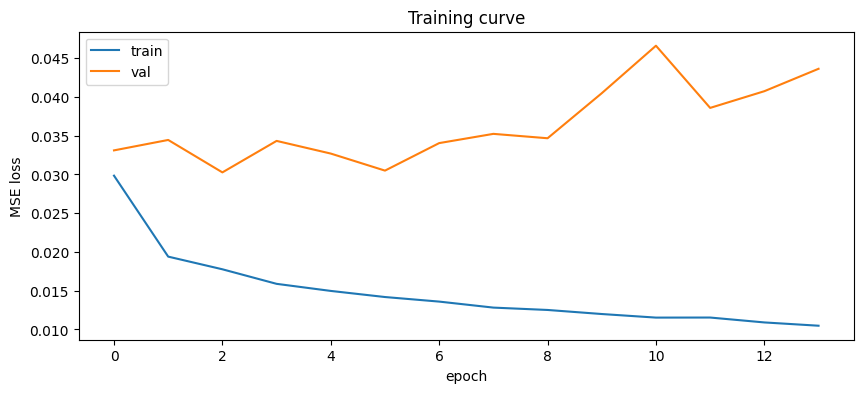

In [15]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history["train_loss"], label="train")
ax.plot(history["val_loss"], label="val")
ax.set_xlabel("epoch"); ax.set_ylabel("MSE loss")
ax.set_title("Training curve"); ax.legend()
plt.show()

## 5. Evaluation

We evaluate on the **5 non-overlapping 30-day test windows** described in
the spec. For each window, we feed the actual 60-day past and ask the
model for 30 days ahead. We then:

1. Inverse-scale predictions back to real units.
2. Compute RMSE / MAE / MAPE per product and aggregated.
3. Compare against naive and seasonal-naive baselines.
4. Save predictions to `data/predictions/lstm_test_predictions.csv` for the team's ensemble.

In [16]:
test_start = pd.Timestamp(splits["test_start"])
test_end   = pd.Timestamp(splits["test_end"])

eval_rows = []
for item_id, idx in product_to_idx.items():
    series = daily[daily["item_id"] == item_id].sort_values("date").reset_index(drop=True)
    test_first_idx = series.index[series["date"] == test_start][0]
    for w in range(5):
        target_start = test_first_idx + w * HORIZON
        target_end = target_start + HORIZON
        if target_end > len(series):
            break
        input_start = target_start - LOOKBACK
        if input_start < 0:
            break
        eval_rows.append({
            "item_id": item_id,
            "prod_idx": idx,
            "X_qty":  series.loc[input_start:target_start - 1, "quantity_scaled"].values.reshape(-1, 1),
            "X_cal":  series.loc[input_start:target_start - 1,
                                 ["dow_sin","dow_cos","dom_sin","dom_cos","month_sin","month_cos"]].values,
            "y_scaled": series.loc[target_start:target_end - 1, "quantity_scaled"].values,
            "y_real":   series.loc[target_start:target_end - 1, "quantity"].values,
            "target_dates": series.loc[target_start:target_end - 1, "date"].values,
        })
print(f"total eval windows: {len(eval_rows)} (expected {50*5} = 250)")

total eval windows: 250 (expected 250 = 250)


In [17]:
X_qty_eval = np.stack([r["X_qty"]    for r in eval_rows]).astype(np.float32)
X_cal_eval = np.stack([r["X_cal"]    for r in eval_rows]).astype(np.float32)
idx_eval   = np.array([r["prod_idx"] for r in eval_rows], dtype=np.int64)
y_eval_scaled = np.stack([r["y_scaled"] for r in eval_rows]).astype(np.float32)
y_eval_real   = np.stack([r["y_real"]   for r in eval_rows]).astype(np.float32)
item_ids_eval = np.array([r["item_id"] for r in eval_rows])

eval_ds = lstm_model.LSTMDataset(X_qty_eval, X_cal_eval, idx_eval, y_eval_scaled)
eval_loader = DataLoader(eval_ds, batch_size=BATCH_SIZE, shuffle=False)

preds_scaled = lstm_model.predict(trained_model, eval_loader, device=DEVICE)
preds_real   = lstm_model.inverse_scale_predictions(preds_scaled, item_ids_eval, scalers)
preds_real   = np.clip(preds_real, 0.0, None)

print("preds_real shape:", preds_real.shape, "  (expected (250, 30))")

preds_real shape: (250, 30)   (expected (250, 30))


In [18]:
m_lstm = lstm_model.compute_metrics(preds_real, y_eval_real)
print("LSTM:", m_lstm)

past_real = np.zeros_like(X_qty_eval[:, :, 0])
for i, item_id in enumerate(item_ids_eval):
    past_real[i] = scalers[item_id].inverse_transform(
        X_qty_eval[i, :, 0].reshape(-1, 1)
    ).flatten()

naive = lstm_model.naive_baseline(past_real, HORIZON)
seasonal = lstm_model.seasonal_naive_baseline(past_real, HORIZON, period=7)

m_naive = lstm_model.compute_metrics(naive, y_eval_real)
m_seas  = lstm_model.compute_metrics(seasonal, y_eval_real)
print("Naive:", m_naive)
print("Seasonal-naive:", m_seas)

LSTM: {'rmse': 127.94642455660863, 'mae': 57.406390436808266, 'mape': 25.98245129879742}
Naive: {'rmse': 172.2634770493704, 'mae': 68.11941394577026, 'mape': 31.921450603803663}
Seasonal-naive: {'rmse': 71.74892821809898, 'mae': 39.887316556294756, 'mape': 24.709434079281515}


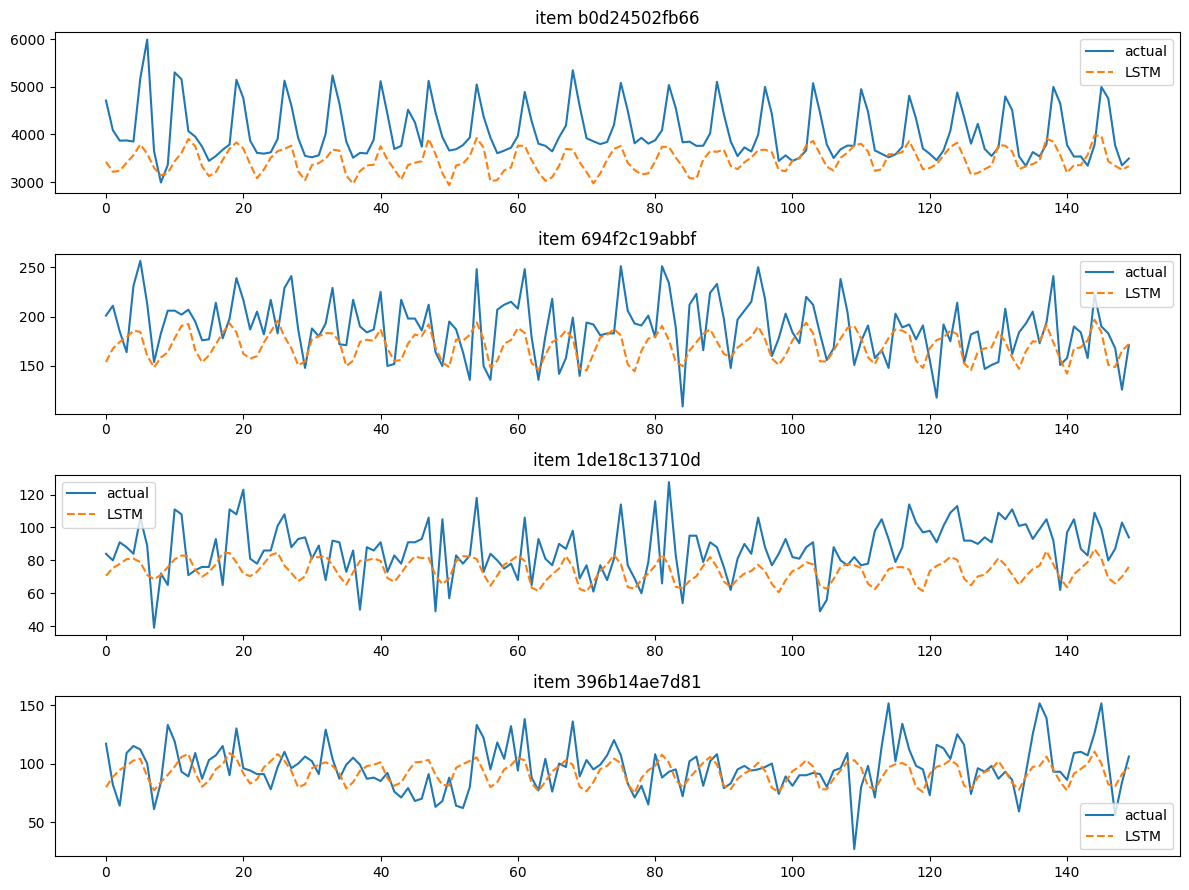

In [19]:
plot_items = [representatives[0], representatives[1], representatives[2],
              list(product_to_idx)[10]]
fig, axes = plt.subplots(len(plot_items), 1, figsize=(12, 9), sharex=False)
for ax, item_id in zip(axes, plot_items):
    mask = item_ids_eval == item_id
    actuals = np.concatenate([r["y_real"] for r in eval_rows if r["item_id"] == item_id])
    preds   = np.concatenate(preds_real[mask])
    ax.plot(actuals, label="actual")
    ax.plot(preds, label="LSTM", linestyle="--")
    ax.set_title(f"item {item_id}")
    ax.legend()
plt.tight_layout(); plt.show()

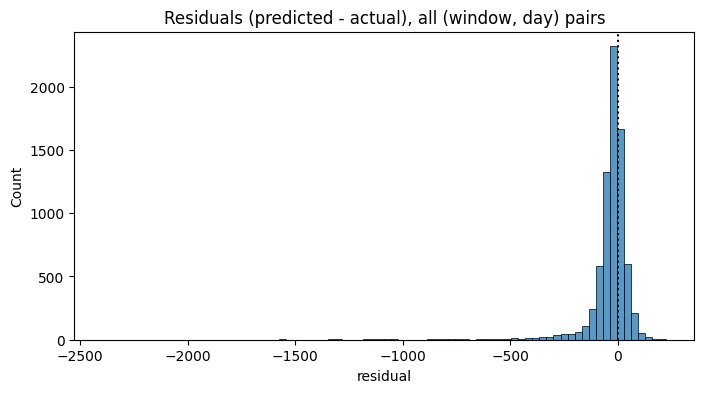

residual mean: -38.809  (~ 0 = unbiased)


In [20]:
residuals = (preds_real - y_eval_real).flatten()
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(residuals, bins=80, ax=ax)
ax.set_title("Residuals (predicted - actual), all (window, day) pairs")
ax.set_xlabel("residual"); ax.axvline(0, color="black", linestyle=":")
plt.show()
print(f"residual mean: {residuals.mean():.3f}  (~ 0 = unbiased)")

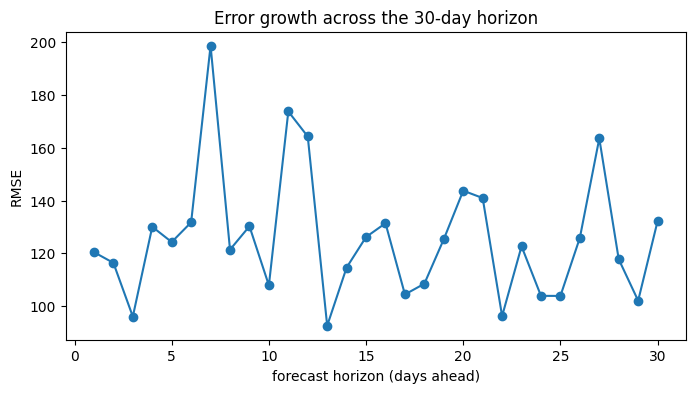

In [21]:
per_day_rmse = np.sqrt(((preds_real - y_eval_real) ** 2).mean(axis=0))
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.arange(1, HORIZON + 1), per_day_rmse, marker="o")
ax.set_xlabel("forecast horizon (days ahead)")
ax.set_ylabel("RMSE")
ax.set_title("Error growth across the 30-day horizon")
plt.show()

In [22]:
from pathlib import Path
Path("data/predictions").mkdir(parents=True, exist_ok=True)

records = []
for r, p in zip(eval_rows, preds_real):
    for d_idx in range(HORIZON):
        records.append({
            "date": pd.Timestamp(r["target_dates"][d_idx]),
            "item_id": r["item_id"],
            "predicted_quantity": float(p[d_idx]),
            "actual_quantity": float(r["y_real"][d_idx]),
        })
predictions_df = pd.DataFrame(records)
predictions_df.to_csv("data/predictions/lstm_test_predictions.csv", index=False)
print(f"saved {len(predictions_df):,} rows to data/predictions/lstm_test_predictions.csv")

saved 7,500 rows to data/predictions/lstm_test_predictions.csv


## 6. Fine-tuning

One-knob-at-a-time grid (8 distinct trainings + 1 final retrain on
train+val combined). Each configuration trains from scratch on the train
slice; we pick the configuration with the lowest val RMSE.

Total trainings: 9. Expect ~30-60 min on CPU; faster on GPU.

In [23]:
DEFAULTS = {
    "hidden_size": 64,
    "num_layers": 2,
    "dropout": 0.2,
    "lookback": 60,
}

CONFIGS = [DEFAULTS.copy()]
for hs in [32, 128]:
    CONFIGS.append({**DEFAULTS, "hidden_size": hs})
for nl in [1]:
    CONFIGS.append({**DEFAULTS, "num_layers": nl})
for dr in [0.1, 0.3]:
    CONFIGS.append({**DEFAULTS, "dropout": dr})
for lb in [30, 90]:
    CONFIGS.append({**DEFAULTS, "lookback": lb})

len(CONFIGS), CONFIGS[:3]

(8,
 [{'hidden_size': 64, 'num_layers': 2, 'dropout': 0.2, 'lookback': 60},
  {'hidden_size': 32, 'num_layers': 2, 'dropout': 0.2, 'lookback': 60},
  {'hidden_size': 128, 'num_layers': 2, 'dropout': 0.2, 'lookback': 60}])

In [24]:
# Reusable: re-create train/val data with a different lookback.
def build_loaders_for_lookback(lookback):
    train_slice2 = daily[daily["date"] <= train_end].copy()
    val_slice2   = daily[(daily["date"] >  train_end - pd.Timedelta(days=lookback))
                         & (daily["date"] <= val_end)].copy()
    Xq_tr, Xc_tr, ix_tr, yy_tr = preprocessing.create_sequences(
        train_slice2, product_to_idx, lookback=lookback, horizon=HORIZON)
    Xq_va, Xc_va, ix_va, yy_va = preprocessing.create_sequences(
        val_slice2,   product_to_idx, lookback=lookback, horizon=HORIZON)
    tl = DataLoader(lstm_model.LSTMDataset(Xq_tr, Xc_tr, ix_tr, yy_tr),
                    batch_size=BATCH_SIZE, shuffle=True)
    vl = DataLoader(lstm_model.LSTMDataset(Xq_va, Xc_va, ix_va, yy_va),
                    batch_size=BATCH_SIZE)
    return tl, vl

In [25]:
import time

results = []
for i, cfg in enumerate(CONFIGS):
    print()
    print(f"=== Config {i+1}/{len(CONFIGS)}: {cfg} ===")
    t0 = time.time()
    torch.manual_seed(42)

    tl, vl = build_loaders_for_lookback(cfg["lookback"])
    m = lstm_model.LSTMForecaster(
        n_products=N_PRODUCTS,
        embed_dim=EMBED_DIM,
        lookback=cfg["lookback"],
        horizon=HORIZON,
        hidden_size=cfg["hidden_size"],
        num_layers=cfg["num_layers"],
        dropout=cfg["dropout"],
        n_calendar=6,
    )
    m, best_val, best_epoch, hist = lstm_model.train_model(
        m, tl, vl, epochs=EPOCHS, lr=LR, patience=PATIENCE,
        device=DEVICE, verbose=False,
    )
    epochs_run = len(hist["val_loss"])
    elapsed = time.time() - t0
    print(f"   best val MSE: {best_val:.4f} | best epoch: {best_epoch} "
          f"| epochs run: {epochs_run} | {elapsed:.0f}s")
    results.append({**cfg, "val_mse": best_val,
                    "best_epoch": best_epoch, "epochs_run": epochs_run})

results_df = pd.DataFrame(results).sort_values("val_mse")
results_df


=== Config 1/8: {'hidden_size': 64, 'num_layers': 2, 'dropout': 0.2, 'lookback': 60} ===


   best val MSE: 0.0288 | best epoch: 4 | epochs run: 15 | 391s

=== Config 2/8: {'hidden_size': 32, 'num_layers': 2, 'dropout': 0.2, 'lookback': 60} ===


   best val MSE: 0.0327 | best epoch: 5 | epochs run: 16 | 149s

=== Config 3/8: {'hidden_size': 128, 'num_layers': 2, 'dropout': 0.2, 'lookback': 60} ===


   best val MSE: 0.0270 | best epoch: 2 | epochs run: 13 | 432s

=== Config 4/8: {'hidden_size': 64, 'num_layers': 1, 'dropout': 0.2, 'lookback': 60} ===


   best val MSE: 0.0264 | best epoch: 4 | epochs run: 15 | 87s

=== Config 5/8: {'hidden_size': 64, 'num_layers': 2, 'dropout': 0.1, 'lookback': 60} ===


   best val MSE: 0.0284 | best epoch: 4 | epochs run: 15 | 227s

=== Config 6/8: {'hidden_size': 64, 'num_layers': 2, 'dropout': 0.3, 'lookback': 60} ===


   best val MSE: 0.0292 | best epoch: 4 | epochs run: 15 | 250s

=== Config 7/8: {'hidden_size': 64, 'num_layers': 2, 'dropout': 0.2, 'lookback': 30} ===


   best val MSE: 0.0319 | best epoch: 3 | epochs run: 14 | 129s

=== Config 8/8: {'hidden_size': 64, 'num_layers': 2, 'dropout': 0.2, 'lookback': 90} ===


   best val MSE: 0.0278 | best epoch: 11 | epochs run: 22 | 377s


,hidden_size,num_layers,dropout,lookback,val_mse,best_epoch,epochs_run
3,64,1,0.2,60,0.026428,4,15
2,128,2,0.2,60,0.027005,2,13
7,64,2,0.2,90,0.027805,11,22
4,64,2,0.1,60,0.028407,4,15
0,64,2,0.2,60,0.028793,4,15
5,64,2,0.3,60,0.029191,4,15
6,64,2,0.2,30,0.031892,3,14
1,32,2,0.2,60,0.032676,5,16


In [26]:
winner = results_df.iloc[0].to_dict()
print(f"winner: {winner}")

combined_slice = daily[daily["date"] <= val_end].copy()
Xq_c, Xc_c, ix_c, yy_c = preprocessing.create_sequences(
    combined_slice, product_to_idx,
    lookback=int(winner["lookback"]), horizon=HORIZON,
)
combined_loader = DataLoader(
    lstm_model.LSTMDataset(Xq_c, Xc_c, ix_c, yy_c),
    batch_size=BATCH_SIZE, shuffle=True,
)
print(f"combined train+val windows: {Xq_c.shape}")

torch.manual_seed(42)
final_model = lstm_model.LSTMForecaster(
    n_products=N_PRODUCTS,
    embed_dim=EMBED_DIM,
    lookback=int(winner["lookback"]),
    horizon=HORIZON,
    hidden_size=int(winner["hidden_size"]),
    num_layers=int(winner["num_layers"]),
    dropout=float(winner["dropout"]),
    n_calendar=6,
)

# Retrain for the BEST EPOCH count from the sweep, not the total epochs run.
WINNER_EPOCHS = int(winner["best_epoch"])
final_model = final_model.to(DEVICE)
opt = torch.optim.Adam(final_model.parameters(), lr=LR)
loss_fn = torch.nn.MSELoss()
for ep in range(1, WINNER_EPOCHS + 1):
    final_model.train()
    total, n = 0.0, 0
    for past_qty, calendar, prod_idx, y in combined_loader:
        past_qty, calendar, prod_idx, y = (
            past_qty.to(DEVICE), calendar.to(DEVICE), prod_idx.to(DEVICE), y.to(DEVICE))
        opt.zero_grad()
        preds = final_model(past_qty, calendar, prod_idx)
        loss = loss_fn(preds, y)
        loss.backward(); opt.step()
        total += loss.item() * y.size(0); n += y.size(0)
    print(f"final-model epoch {ep:3d} | train MSE {total/n:.4f}")

winner: {'hidden_size': 64.0, 'num_layers': 1.0, 'dropout': 0.2, 'lookback': 60.0, 'val_mse': 0.026427943057590917, 'best_epoch': 4.0, 'epochs_run': 15.0}


combined train+val windows: (26000, 60, 1)


final-model epoch   1 | train MSE 0.0329


final-model epoch   2 | train MSE 0.0203


final-model epoch   3 | train MSE 0.0191


final-model epoch   4 | train MSE 0.0175


In [27]:
WINNER_LOOKBACK = int(winner["lookback"])

eval_rows_final = []
for item_id, idx in product_to_idx.items():
    series = daily[daily["item_id"] == item_id].sort_values("date").reset_index(drop=True)
    test_first_idx = series.index[series["date"] == test_start][0]
    for w in range(5):
        target_start = test_first_idx + w * HORIZON
        target_end = target_start + HORIZON
        if target_end > len(series): break
        input_start = target_start - WINNER_LOOKBACK
        if input_start < 0: break
        eval_rows_final.append({
            "item_id": item_id,
            "prod_idx": idx,
            "X_qty":  series.loc[input_start:target_start - 1, "quantity_scaled"].values.reshape(-1, 1),
            "X_cal":  series.loc[input_start:target_start - 1,
                                 ["dow_sin","dow_cos","dom_sin","dom_cos","month_sin","month_cos"]].values,
            "y_scaled": series.loc[target_start:target_end - 1, "quantity_scaled"].values,
            "y_real":   series.loc[target_start:target_end - 1, "quantity"].values,
            "target_dates": series.loc[target_start:target_end - 1, "date"].values,
        })

X_qty_f = np.stack([r["X_qty"]    for r in eval_rows_final]).astype(np.float32)
X_cal_f = np.stack([r["X_cal"]    for r in eval_rows_final]).astype(np.float32)
idx_f   = np.array([r["prod_idx"] for r in eval_rows_final], dtype=np.int64)
y_f_scaled = np.stack([r["y_scaled"] for r in eval_rows_final]).astype(np.float32)
y_f_real   = np.stack([r["y_real"]   for r in eval_rows_final]).astype(np.float32)
items_f    = np.array([r["item_id"] for r in eval_rows_final])

eval_loader_final = DataLoader(
    lstm_model.LSTMDataset(X_qty_f, X_cal_f, idx_f, y_f_scaled),
    batch_size=BATCH_SIZE, shuffle=False,
)
preds_f_scaled = lstm_model.predict(final_model, eval_loader_final, device=DEVICE)
preds_f_real   = np.clip(
    lstm_model.inverse_scale_predictions(preds_f_scaled, items_f, scalers),
    0.0, None,
)
m_final = lstm_model.compute_metrics(preds_f_real, y_f_real)
print("FINAL TUNED LSTM:", m_final)
print("Naive baseline:  ", m_naive)
print("Seasonal naive:  ", m_seas)

FINAL TUNED LSTM: {'rmse': 97.96980688292427, 'mae': 47.104101485951745, 'mape': 24.079925910986354}
Naive baseline:   {'rmse': 172.2634770493704, 'mae': 68.11941394577026, 'mape': 31.921450603803663}
Seasonal naive:   {'rmse': 71.74892821809898, 'mae': 39.887316556294756, 'mape': 24.709434079281515}


In [28]:
from pathlib import Path
Path("models").mkdir(exist_ok=True)

torch.save(final_model.state_dict(), "models/lstm_final.pt")
with open("models/lstm_config.json", "w") as f:
    json.dump({
        "n_products": N_PRODUCTS,
        "embed_dim":  EMBED_DIM,
        "lookback":   WINNER_LOOKBACK,
        "horizon":    HORIZON,
        "hidden_size": int(winner["hidden_size"]),
        "num_layers":  int(winner["num_layers"]),
        "dropout":     float(winner["dropout"]),
        "n_calendar":  6,
        "winner_best_epoch": WINNER_EPOCHS,
    }, f, indent=2)

records_final = []
for r, p in zip(eval_rows_final, preds_f_real):
    for d_idx in range(HORIZON):
        records_final.append({
            "date": pd.Timestamp(r["target_dates"][d_idx]),
            "item_id": r["item_id"],
            "predicted_quantity": float(p[d_idx]),
            "actual_quantity": float(r["y_real"][d_idx]),
        })
pd.DataFrame(records_final).to_csv("data/predictions/lstm_test_predictions.csv", index=False)
print("saved models/lstm_final.pt, models/lstm_config.json, data/predictions/lstm_test_predictions.csv")

saved models/lstm_final.pt, models/lstm_config.json, data/predictions/lstm_test_predictions.csv


### What we learned

(Fill in after the grid runs:)

- Which knob mattered most? (Compare val MSE across configs.)
- What surprised you?
- What would you try next? (E.g., a longer horizon, more products,
  Bayesian optimization, adding price as a feature.)